<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Machine%20Learning/Projetos/Departamento%20RP/Dp_de_rela%C3%A7%C3%B5es_publicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
reviews_df = pd.read_csv("/content/amazon_alexa.tsv", sep = "\t")

In [53]:
reviews_df.shape

(3150, 5)

In [54]:
reviews_df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [55]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [56]:
reviews_df.describe()

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


In [57]:
reviews_df["verified_reviews"]

,verified_reviews
0,Love my Echo!
1,Loved it!
2,"Sometimes while playing a game, you can answer..."
3,I have had a lot of fun with this thing. My 4 ...
4,Music
...,...
3145,"Perfect for kids, adults and everyone in betwe..."
3146,"Listening to music, searching locations, check..."
3147,"I do love these things, i have them running my..."
3148,Only complaint I have is that the sound qualit...


# Exploração dos dados

<Axes: >

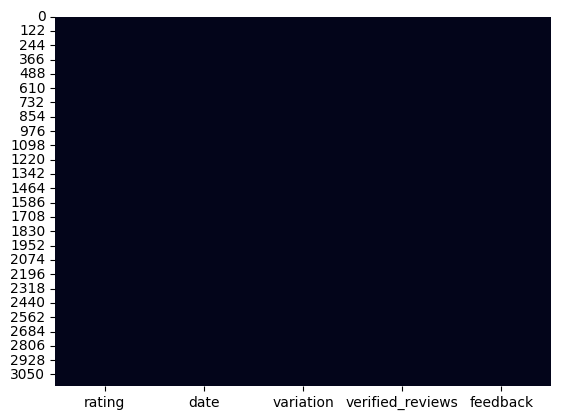

In [58]:
sns.heatmap(reviews_df.isnull(), cbar = False)

In [59]:
reviews_df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [60]:
reviews_df.dropna(inplace = True)

In [61]:
reviews_df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,0
feedback,0


array([[<Axes: title={'center': 'rating'}>,
        <Axes: title={'center': 'feedback'}>]], dtype=object)

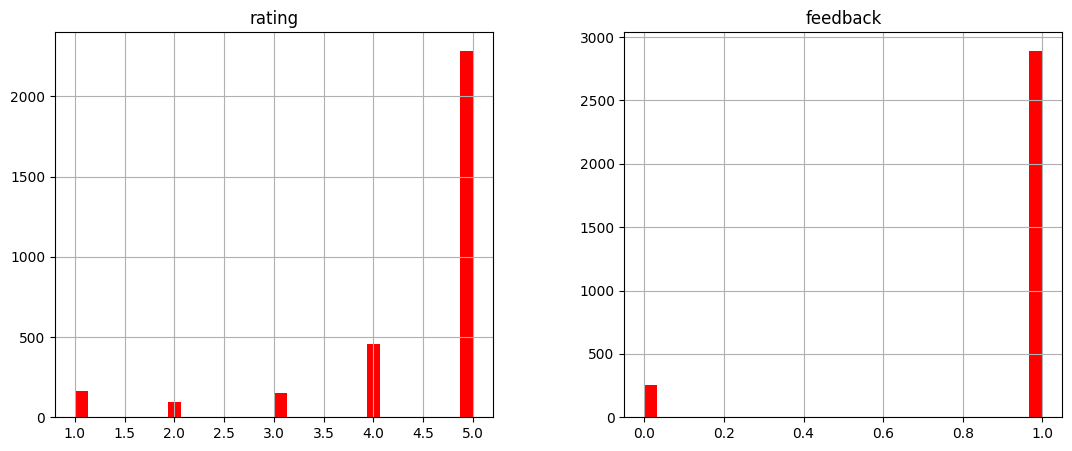

In [62]:
reviews_df.hist(bins = 30, figsize = (13, 5), color = "r")

In [63]:
reviews_df["length"] = reviews_df["verified_reviews"].apply(len)
reviews_df.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


<Axes: ylabel='Frequency'>

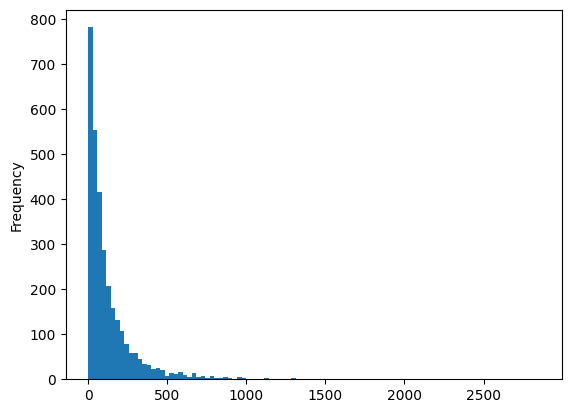

In [64]:
reviews_df["length"].plot(bins = 100, kind = "hist")

In [65]:
reviews_df.length.describe()

,length
count,3149.000000
mean,132.090187
std,182.114569
min,1.000000
25%,30.000000
50%,74.000000
75%,165.000000
max,2851.000000


In [66]:
reviews_df[reviews_df["length"] == 2851]["verified_reviews"].iloc[0]

"Incredible piece of technology.I have this right center of my living room on an island kitchen counter. The mic and speaker goes in every direction and the quality of the sound is quite good. I connected the Echo via Bluetooth to my Sony soundbar on my TV but find the Echo placement and 360 sound more appealing. It's no audiophile equipment but there is good range and decent bass. The sound is more than adequate for any indoor entertaining and loud enough to bother neighbors in my building. The knob on the top works great for adjusting volume. This is my first Echo device and I would imagine having to press volume buttons (on the Echo 2) a large inconvenience and not as precise. For that alone I would recommend this over the regular Echo (2nd generation).The piece looks quality and is quite sturdy with some weight on it. The rubber material on the bottom has a good grip on the granite counter-- my cat can even rub her scent on it without tipping it over.This order came with a free Phi

In [67]:
reviews_df[reviews_df["length"] == 1]["verified_reviews"].iloc[0]

'😍'

In [68]:
positive = reviews_df[reviews_df["feedback"] == 1]
negative = reviews_df[reviews_df["feedback"]== 0]

In [69]:
positive.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [70]:
negative.head()

,rating,date,variation,verified_reviews,feedback,length
46,2,30-Jul-18,Charcoal Fabric,"It's like Siri, in fact, Siri answers more acc...",0,163
111,2,30-Jul-18,Charcoal Fabric,Sound is terrible if u want good music too get...,0,53
141,1,30-Jul-18,Charcoal Fabric,Not much features.,0,18
162,1,30-Jul-18,Sandstone Fabric,"Stopped working after 2 weeks ,didn't follow c...",0,87
176,2,30-Jul-18,Heather Gray Fabric,Sad joke. Worthless.,0,20


In [71]:
negative.describe()

,rating,feedback,length
count,256.000000,256.0,256.000000
mean,1.371094,0.0,216.066406
std,0.484044,0.0,236.417642
min,1.000000,0.0,1.000000
25%,1.000000,0.0,53.000000
50%,1.000000,0.0,138.000000
75%,2.000000,0.0,291.750000
max,2.000000,0.0,1686.000000


In [72]:
positive.describe()

,rating,feedback,length
count,2893.000000,2893.0,2893.000000
mean,4.737643,1.0,124.659177
std,0.546544,0.0,174.624491
min,3.000000,1.0,1.000000
25%,5.000000,1.0,29.000000
50%,5.000000,1.0,69.000000
75%,5.000000,1.0,154.000000
max,5.000000,1.0,2851.000000


/tmp/ipython-input-446275833.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "variation", y = "rating", data = reviews_df, palette = "deep");


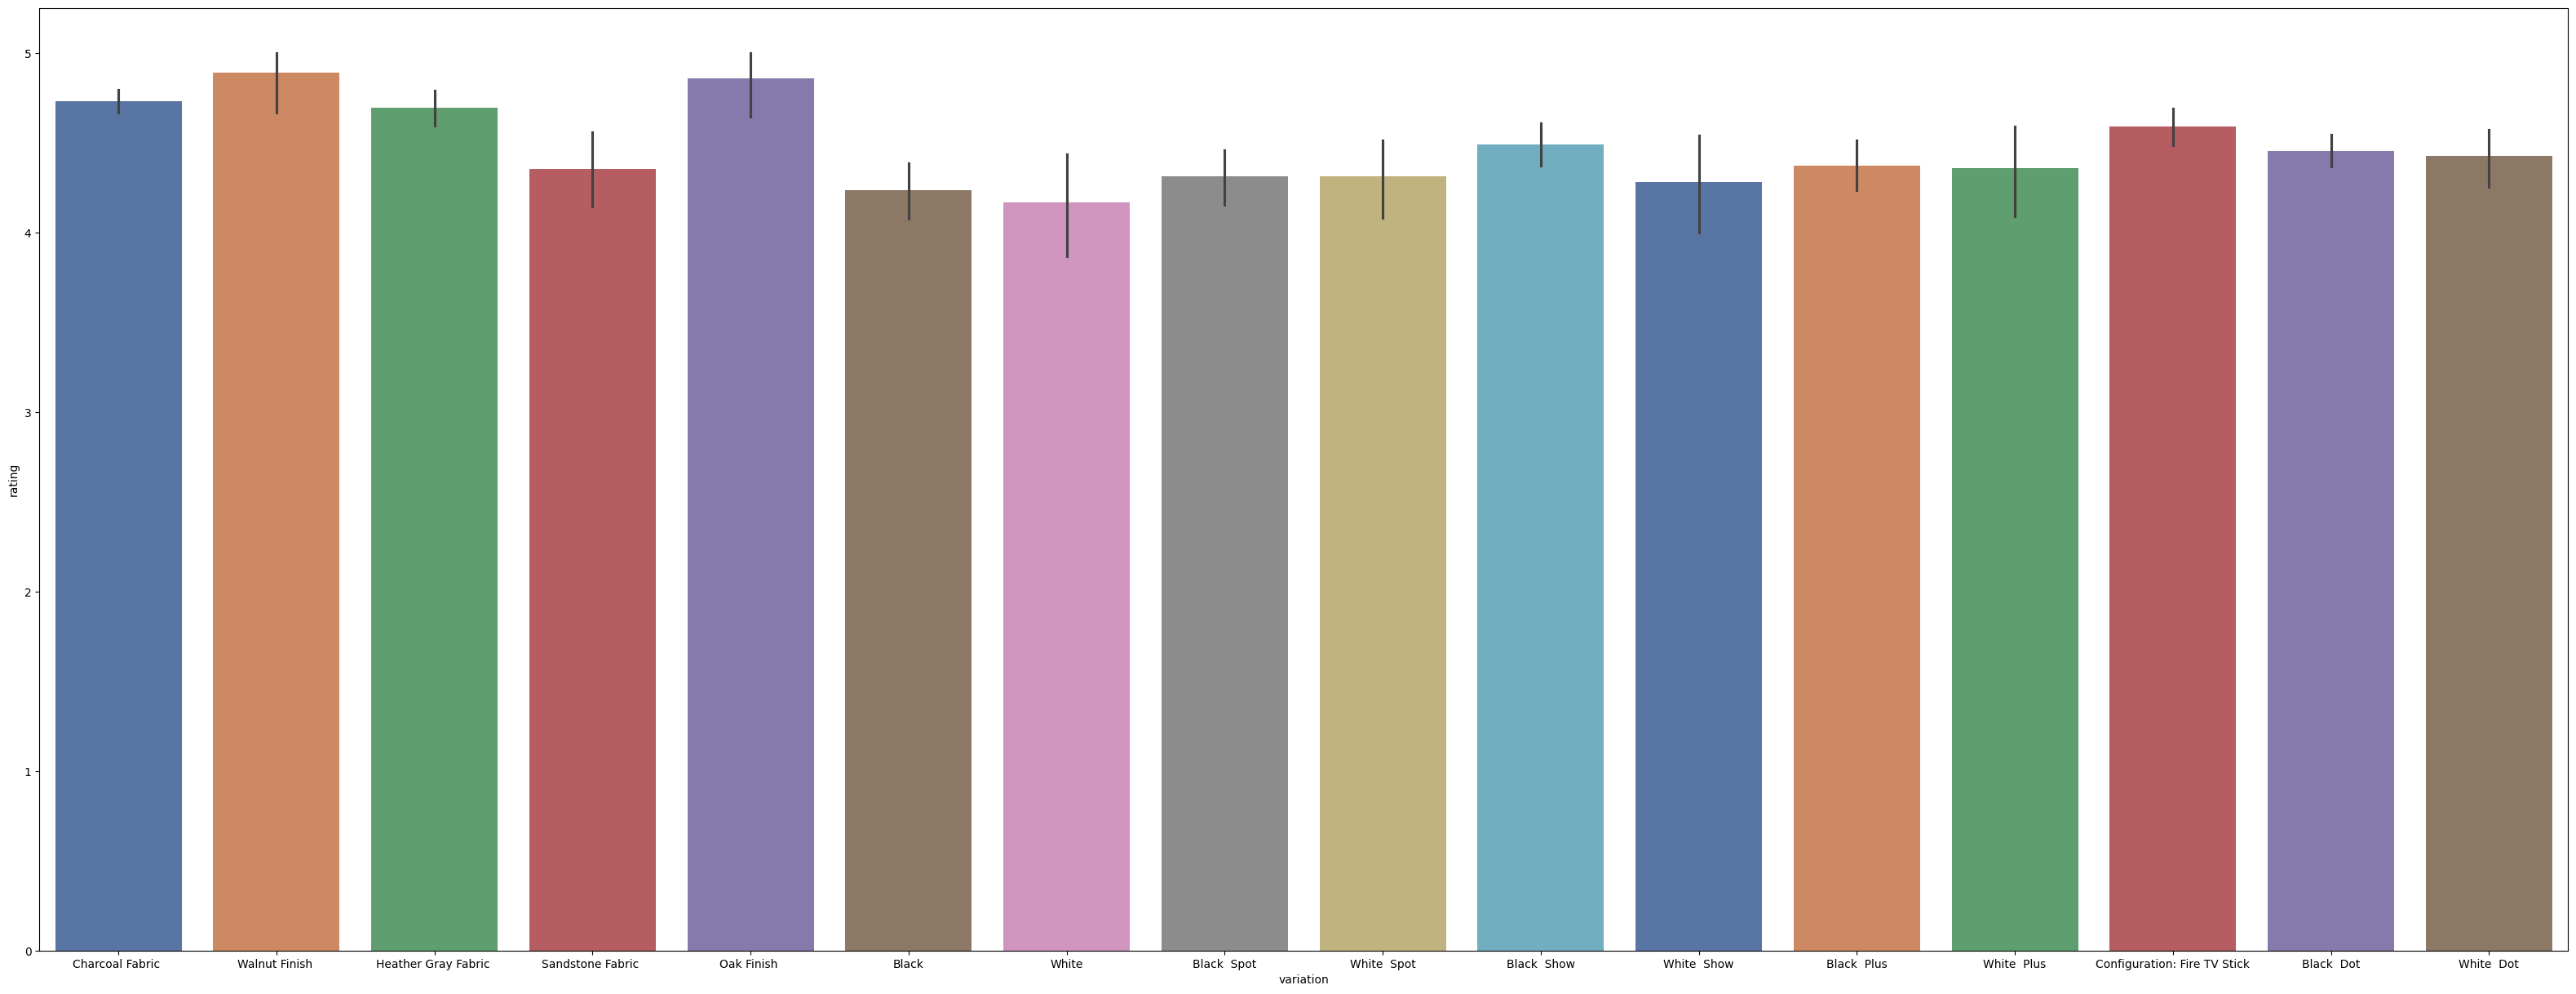

In [73]:
plt.figure(figsize = (40, 15))
sns.barplot(x = "variation", y = "rating", data = reviews_df, palette = "deep");

In [74]:
sentences = reviews_df["verified_reviews"].tolist()
len(sentences)

3149

In [75]:
sentences_as_one_string = " ".join(sentences)

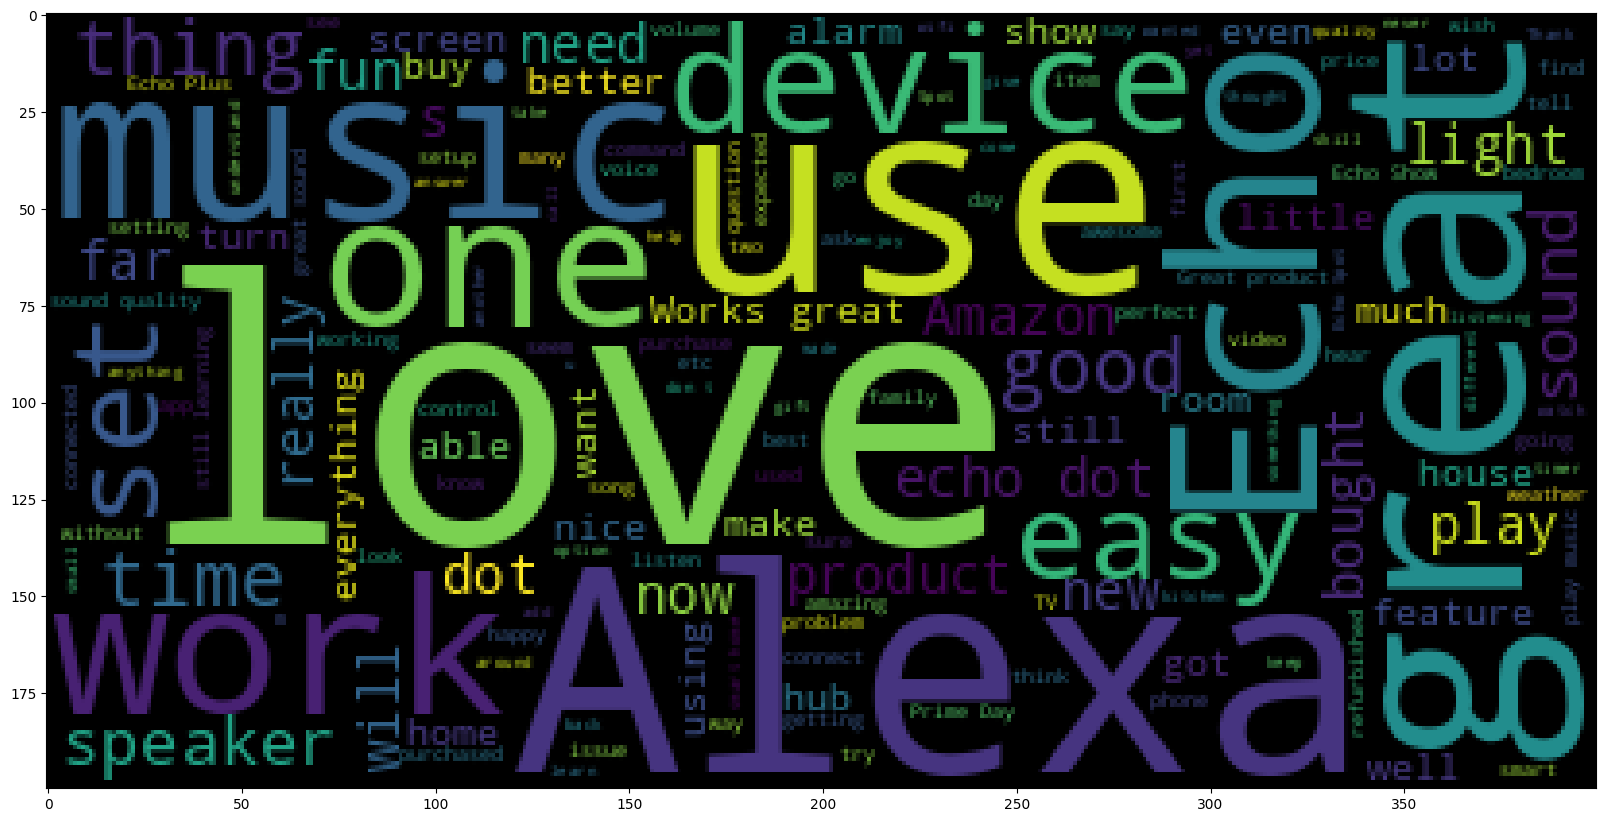

In [76]:
from wordcloud import WordCloud
plt.figure(figsize = (20, 20))
plt.imshow(WordCloud().generate(sentences_as_one_string));

In [77]:
negative_list = negative["verified_reviews"].tolist()
negative_sentence_as_one_string = " ".join(negative_list)

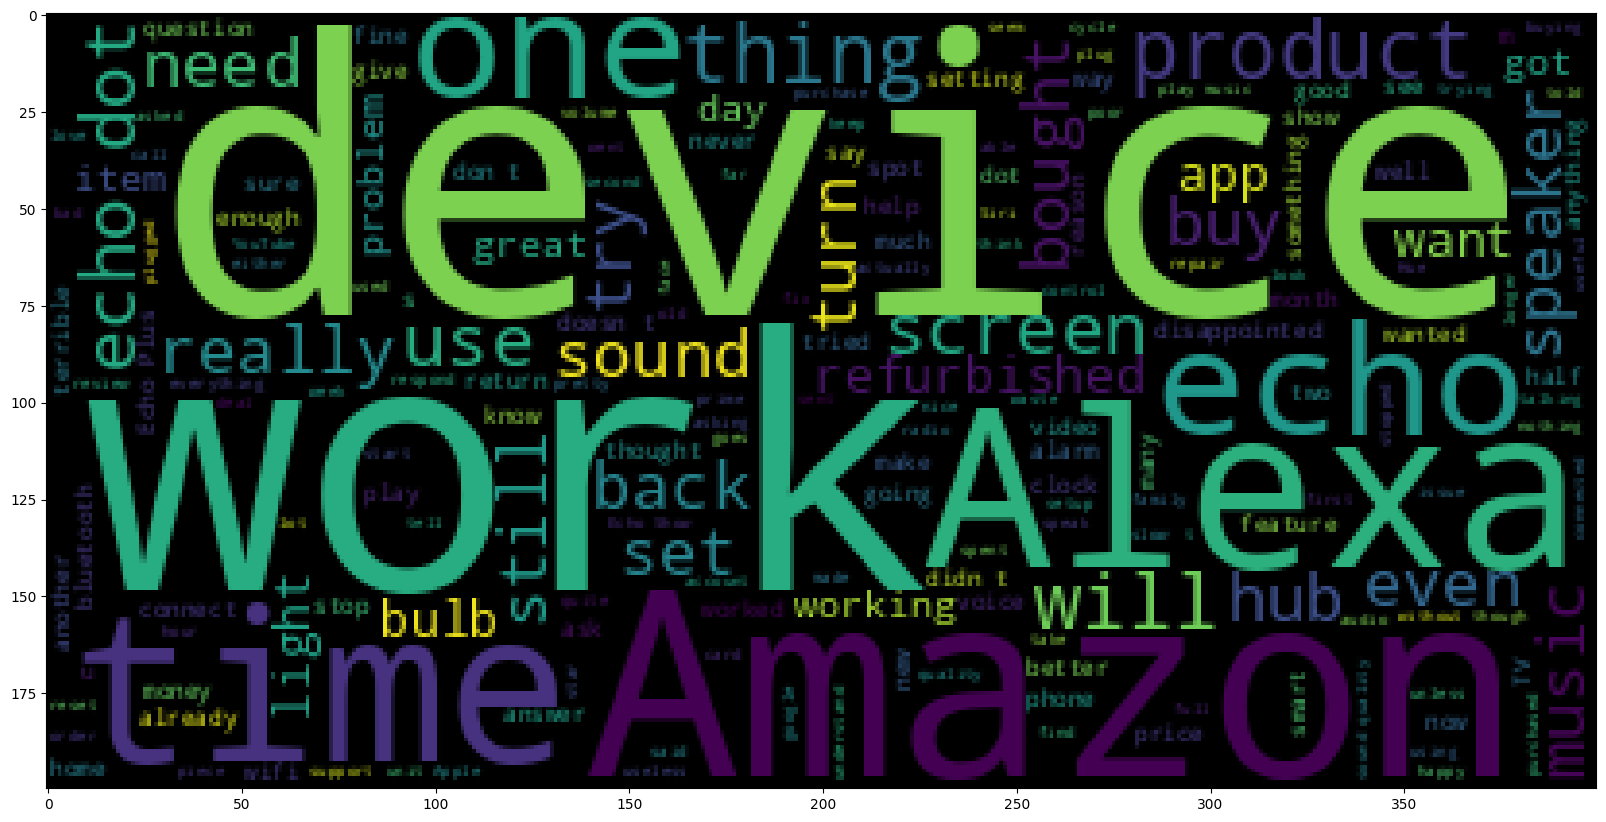

In [78]:
plt.figure(figsize = (20, 20))
plt.imshow(WordCloud().generate(negative_sentence_as_one_string));

In [79]:
positive_list = positive["verified_reviews"].tolist()
positive_sentence_as_one_string = " ".join(positive_list)

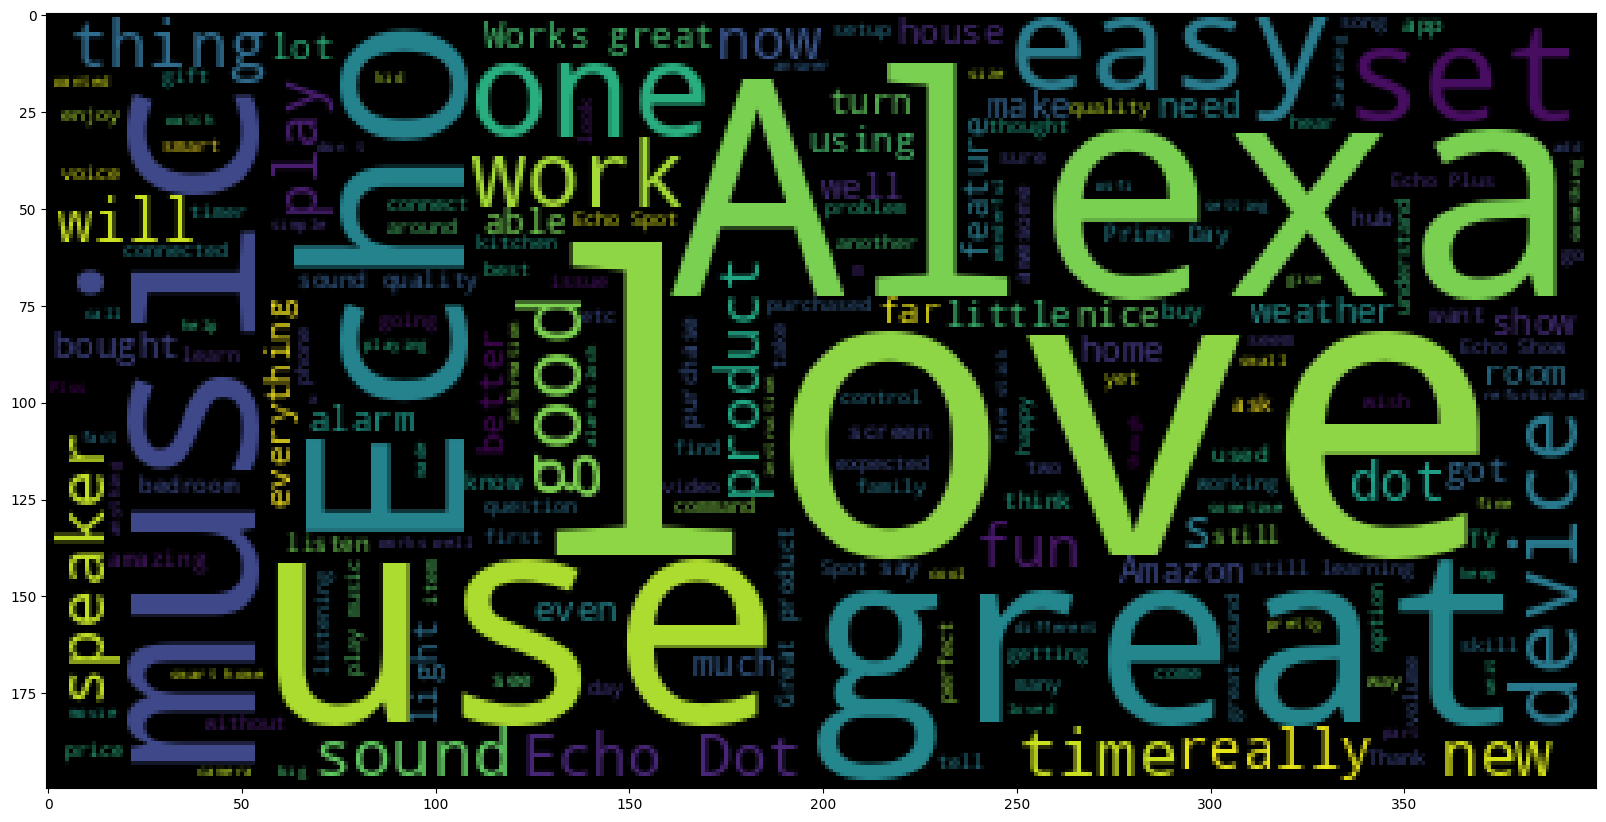

In [80]:
plt.figure(figsize = (20, 20))
plt.imshow(WordCloud().generate(positive_sentence_as_one_string));

# Limpeza dos dados

In [81]:
reviews_df = reviews_df.drop(["date", "rating", "length"], axis = 1)

In [82]:
reviews_df

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1
...,...,...,...
3145,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,Black Dot,"Listening to music, searching locations, check...",1
3147,Black Dot,"I do love these things, i have them running my...",1
3148,White Dot,Only complaint I have is that the sound qualit...,1


In [83]:
reviews_df["variation"].unique()

array(['Charcoal Fabric ', 'Walnut Finish ', 'Heather Gray Fabric ',
       'Sandstone Fabric ', 'Oak Finish ', 'Black', 'White',
       'Black  Spot', 'White  Spot', 'Black  Show', 'White  Show',
       'Black  Plus', 'White  Plus', 'Configuration: Fire TV Stick',
       'Black  Dot', 'White  Dot'], dtype=object)

In [84]:
X_cat = reviews_df[["variation"]]
X_cat

,variation
0,Charcoal Fabric
1,Charcoal Fabric
2,Walnut Finish
3,Charcoal Fabric
4,Charcoal Fabric
...,...
3145,Black Dot
3146,Black Dot
3147,Black Dot
3148,White Dot


In [85]:
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder()

X_cat = onehotencoder.fit_transform(X_cat).toarray()

In [86]:
X_cat = pd.DataFrame(X_cat)
type(X_cat)

pandas.core.frame.DataFrame

In [87]:
reviews_df.drop(["variation"], axis = 1, inplace = True)

In [88]:
reviews_df = pd.concat([reviews_df, X_cat], axis = 1)
reviews_df.head()

,verified_reviews,feedback,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Love my Echo!,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Loved it!,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"Sometimes while playing a game, you can answer...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,I have had a lot of fun with this thing. My 4 ...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Music,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Remoção de pontuação dos textos - Remoção de stop words

In [89]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [90]:
from sklearn.feature_extraction.text import CountVectorizer

In [91]:
import nltk

In [92]:
from nltk.corpus import stopwords
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [93]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## pipeline para limpeza dos textos

In [94]:
def message_cleaning(message):
  if pd.isna(message) or not isinstance(message, str):
      return []
  text = [char for char in  message if char not in string.punctuation]
  text = "".join(text)

  text = [word for word in text.split() if word.lower() not in stopwords.words("english")]
  return text

In [95]:
# Não precisa executar essa linha caso use o analyzer no CountVectorizer
reviews_df_clean = reviews_df["verified_reviews"].apply(message_cleaning)

In [96]:
# reviews_df["verified_reviews"] = reviews_df["verified_reviews"].fillna("")

In [97]:
reviews_df = reviews_df.dropna()

In [98]:
vectorizer = CountVectorizer(analyzer=message_cleaning)
reviews_count_vectorizer = vectorizer.fit_transform(reviews_df["verified_reviews"])

In [99]:
print(vectorizer.get_feature_names_out())

['072318' '1' '10' ... '😬' '😳' '🤓']


In [100]:
len(vectorizer.get_feature_names_out())

5211

In [101]:
print(reviews_count_vectorizer.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [102]:
reviews_df.drop(["verified_reviews"], axis = 1, inplace = True)
reviews_df.head()

,feedback,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [103]:
type(reviews_count_vectorizer)

scipy.sparse._csr.csr_matrix

In [104]:
reviews = pd.DataFrame(reviews_count_vectorizer.toarray())
type(reviews)

pandas.core.frame.DataFrame

In [105]:
reviews_df = reviews_df.reset_index(drop=True)
reviews = reviews.reset_index(drop=True)

In [106]:
reviews_df = pd.concat([reviews_df, reviews], axis = 1)

In [107]:
reviews_df

,feedback,0,1,2,3,4,5,6,7,8,...,5201,5202,5203,5204,5205,5206,5207,5208,5209,5210
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3144,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3145,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3146,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [108]:
reviews_df.fillna(0)

,feedback,0,1,2,3,4,5,6,7,8,...,5201,5202,5203,5204,5205,5206,5207,5208,5209,5210
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3144,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3145,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3146,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [109]:
X = reviews_df.drop(["feedback"], axis = 1)
y = reviews_df["feedback"]

## Treinamento e avaliação do Naive Bayes

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [111]:
from sklearn.naive_bayes import MultinomialNB

In [112]:
X_train.shape, X_test.shape

((2518, 5227), (630, 5227))

In [113]:
X_train = X_train.fillna(0)

In [114]:
y_train = y_train.fillna(0)

In [115]:
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, y_train)

MultinomialNB()

In [116]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [117]:
y_pred = naive_bayes.predict(X_test)

In [118]:
accuracy_score(y_test, y_pred)

0.9238095238095239

In [119]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 13,  35],
       [ 13, 569]])

<Axes: >

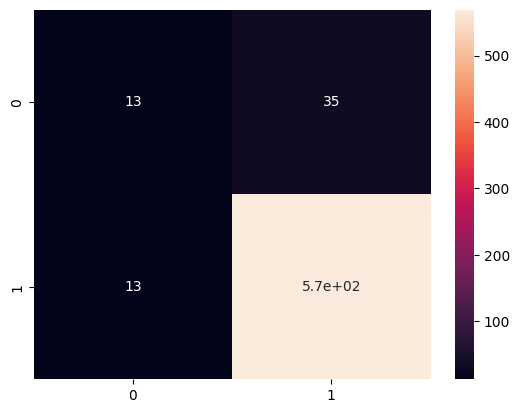

In [120]:
sns.heatmap(cm, annot = True)

In [121]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.50      0.27      0.35        48
         1.0       0.94      0.98      0.96       582

    accuracy                           0.92       630
   macro avg       0.72      0.62      0.66       630
weighted avg       0.91      0.92      0.91       630



## Regressão Logistica

In [122]:
from sklearn.linear_model import LogisticRegression

In [123]:
logistic = LogisticRegression()
logistic.fit(X_train, y_train)

LogisticRegression()

In [124]:
y_pred = logistic.predict(X_test)

In [125]:
accuracy_score(y_test, y_pred)

0.9333333333333333

In [126]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.64      0.29      0.40        48
         1.0       0.94      0.99      0.96       582

    accuracy                           0.93       630
   macro avg       0.79      0.64      0.68       630
weighted avg       0.92      0.93      0.92       630



## Classificação de uma frase

In [127]:
import pickle

In [128]:
with open("text_classifier.pkl", "wb") as f:
  pickle.dump([naive_bayes, onehotencoder, vectorizer], f)

In [129]:
with open("text_classifier.pkl", "rb") as f:
  model, onehot, vector = pickle.load(f)

In [130]:
model

MultinomialNB()

In [131]:
onehot

OneHotEncoder()

In [132]:
vector

CountVectorizer(analyzer=<function message_cleaning at 0x7993a66f14e0>)

In [133]:
negative.head()

,rating,date,variation,verified_reviews,feedback,length
46,2,30-Jul-18,Charcoal Fabric,"It's like Siri, in fact, Siri answers more acc...",0,163
111,2,30-Jul-18,Charcoal Fabric,Sound is terrible if u want good music too get...,0,53
141,1,30-Jul-18,Charcoal Fabric,Not much features.,0,18
162,1,30-Jul-18,Sandstone Fabric,"Stopped working after 2 weeks ,didn't follow c...",0,87
176,2,30-Jul-18,Heather Gray Fabric,Sad joke. Worthless.,0,20


In [134]:
negative_text = negative.iloc[0:1, [2,3]]
negative_text

,variation,verified_reviews
46,Charcoal Fabric,"It's like Siri, in fact, Siri answers more acc..."


In [135]:
X_cat = negative_text[["variation"]]
X_cat

,variation
46,Charcoal Fabric


In [136]:
X_cat = onehot.transform(X_cat).toarray()
X_cat = pd.DataFrame(X_cat)
X_cat

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [137]:
negative_text

,variation,verified_reviews
46,Charcoal Fabric,"It's like Siri, in fact, Siri answers more acc..."


In [138]:
X_cat.index = negative_text.index

In [139]:
negative_df = pd.concat([negative_text, X_cat], axis = 1)
negative_df

,variation,verified_reviews,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
46,Charcoal Fabric,"It's like Siri, in fact, Siri answers more acc...",0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [140]:
negative_df.drop(["variation"], axis = 1, inplace = True)
negative_df

,verified_reviews,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
46,"It's like Siri, in fact, Siri answers more acc...",0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [141]:
negative_countverctor = vector.transform(negative_df["verified_reviews"])

In [142]:
negative_countverctor

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 17 stored elements and shape (1, 5211)>

In [143]:
negative_df.drop(["verified_reviews"], axis = 1, inplace = True)
negative_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
46,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [144]:
review = pd.DataFrame(negative_countverctor.toarray())
review

,0,1,2,3,4,5,6,7,8,9,...,5201,5202,5203,5204,5205,5206,5207,5208,5209,5210
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [145]:
negative_df.index = review.index

In [146]:
negative_final = pd.concat([negative_df, review], axis = 1)
negative_final

,0,1,2,3,4,5,6,7,8,9,...,5201,5202,5203,5204,5205,5206,5207,5208,5209,5210
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [147]:
model.predict(negative_final)

array([1.])

In [148]:
model.predict_proba(negative_final)

array([[0.02281063, 0.97718937]])